In [ ]:
#SV enrichment script with telomere/centromere highlights
# This workflow bins SV breakpoints across each chromosome, then compares
# observed local SV density to the chromosome-wide expected background.
# It highlights telomeric, peritelomeric, and centromeric regions to test
# whether specific SV classes show positional enrichment near these landmarks.

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(purrr)
  library(patchwork)
})

In [4]:
# --------------------------------------------------
# Paths
# --------------------------------------------------
data_dir <- "/home/mjehangir/telomere-sv-analysis/data/"
setwd(data_dir)

In [5]:
arm_file <- "/home/mjehangir/chm13_chrs_arms/cytoBandMapped.bed"
telomere_file <- "chm13v2.0_telomere.bed.txt"
sv_file <- "SVs_merged_all_samples_SVs_v7.txt"
#out_file <- "/scratch/mjehangir/manuscript_figures/manuscript_data/sv_dual_axis_enrichment.pdf"

In [10]:
# --------------------------------------------------
# Load chromosome structure annotations
# --------------------------------------------------
# These annotations define p arm, q arm, centromere, and telomeric intervals.
df_arms <- read.delim(arm_file, header = TRUE)
t2t_telomere <- read.csv(telomere_file, header = TRUE, sep = "\t")

colnames(df_arms) <- c("chr", "start", "end", "band", "stain")

In [11]:
t2t_telomere <- read.csv(telomere_file, header = FALSE, sep = "\t")
colnames(t2t_telomere) <- c("chr", "start", "end")

head(t2t_telomere)
colnames(t2t_telomere)

,chr,start,end
,<chr>,<int>,<int>
1,chr1,0,3000
2,chr1,248384000,248387328
3,chr2,0,3600
4,chr2,242693800,242696752
5,chr3,0,2800
6,chr3,200904400,200905400


[1] "chr"   "start" "end"

In [16]:
t2t_telomere <- t2t_telomere %>%
  group_by(chr) %>%
  arrange(start, .by_group = TRUE) %>%
  mutate(
    telomere_arm = case_when(
      row_number() == 1 ~ "p",
      row_number() == n() ~ "q",
      TRUE ~ NA_character_
    )
  ) %>%
  ungroup()

In [14]:
# --------------------------------------------------
# Load SV calls and prepare coordinates
# --------------------------------------------------
sv_data_clean <- read.csv(sv_file, sep = "\t", header = TRUE) %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end)
  )

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `end = as.numeric(end)`.
Caused by warning:
! NAs introduced by coercion”


In [ ]:
# Load chromosome structure annotations
df_arms <- read.delim(arm_file, header = TRUE)
t2t_telomere <- read.csv(telomere_file, header = FALSE, sep = "\t")

colnames(df_arms) <- c("chr", "start", "end", "band", "stain")
colnames(t2t_telomere) <- c("chr", "start", "end")

# Label telomeres by chromosome end
t2t_telomere <- t2t_telomere %>%
  group_by(chr) %>%
  arrange(start, .by_group = TRUE) %>%
  mutate(
    telomere_arm = case_when(
      row_number() == 1 ~ "p",
      row_number() == n() ~ "q",
      TRUE ~ NA_character_
    )
  ) %>%
  ungroup()

In [17]:
# Collapse chm13 cytobands into structural compartments
df_arms <- df_arms %>%
  mutate(
    arm = case_when(
      stain == "acen" ~ "centromere",
      grepl("^p", band) ~ "p",
      TRUE ~ "q"
    ),
    size = end - start
  ) %>%
  group_by(chr, arm) %>%
  summarise(
    total_size = sum(size),
    start = min(start),
    end = max(end),
    .groups = "drop"
  )

# Build merged annotation table
t2t_merged_data <- bind_rows(
  df_arms %>% select(chr, arm, start, end),
  t2t_telomere %>%
    mutate(arm = paste0(telomere_arm, "_telomere")) %>%
    select(chr, arm, start, end)
) %>%
  arrange(chr, start)

head(t2t_merged_data)

chr,arm,start,end
<chr>,<chr>,<int>,<int>
chr1,p_telomere,0,3000
chr1,p,1735965,121796048
chr1,centromere,121796048,126300487
chr1,q,126300487,248387328
chr1,q_telomere,248384000,248387328
chr10,p,0,39633793


In [18]:
# --------------------------------------------------
# Highlight regions along each chromosome
# --------------------------------------------------
# Telomeric intervals come directly from the annotation file.
# Peritelomeric intervals are defined as the outermost 3% of each chromosome.
# Centromeric intervals come from the collapsed cytoband annotation.
peritel_pct <- 0.03
chromosomes <- paste0("chr", 1:22)

telomeres <- t2t_merged_data %>%
  filter(arm %in% c("p_telomere", "q_telomere")) %>%
  mutate(highlight_type = "Telomeric") %>%
  select(chr, arm, start, end, highlight_type)

centromeres <- t2t_merged_data %>%
  filter(arm == "centromere") %>%
  mutate(highlight_type = "Centromeric") %>%
  select(chr, arm, start, end, highlight_type)

chr_lengths <- t2t_merged_data %>%
  group_by(chr) %>%
  summarise(chr_len = max(end), .groups = "drop")

peritelomeric_pct <- chr_lengths %>%
  mutate(
    p_start = 0,
    p_end = chr_len * peritel_pct,
    q_start = chr_len * (1 - peritel_pct),
    q_end = chr_len
  ) %>%
  pivot_longer(
    cols = c(p_start:p_end, q_start:q_end),
    names_to = c("arm", "bound"),
    names_pattern = "(.+)_(.+)",
    values_to = "coord"
  ) %>%
  pivot_wider(names_from = bound, values_from = coord) %>%
  mutate(highlight_type = "Peritelomeric (3%)") %>%
  select(chr, arm, start, end, highlight_type)

highlight_regions <- bind_rows(telomeres, peritelomeric_pct, centromeres)

In [19]:
# --------------------------------------------------
# Bin SVs and compute enrichment
# --------------------------------------------------
# Each chromosome is split into 1 Mb bins.
# For each SV type, enrichment is defined as local density divided by
# chromosome-wide expected density for that SV type on that chromosome.
bin_size <- 1e6

process_chromosome <- function(chr_name) {
  sv_chr <- sv_data_clean %>% filter(chr == chr_name)
  seg_chr <- t2t_merged_data %>% filter(chr == chr_name)

  if (nrow(sv_chr) == 0 || nrow(seg_chr) == 0) {
    return(tibble())
  }

  chr_len <- max(seg_chr$end, na.rm = TRUE)

  bins_chr <- tibble(
    bin = 1:ceiling(chr_len / bin_size),
    start = (bin - 1) * bin_size,
    end = pmin(bin * bin_size, chr_len)
  )

  sv_types <- sort(unique(sv_chr$type))

  sv_chr %>%
    mutate(bin = floor(start / bin_size) + 1) %>%
    filter(bin <= nrow(bins_chr)) %>%
    count(type, bin, name = "count") %>%
    complete(type = sv_types, bin = 1:nrow(bins_chr), fill = list(count = 0)) %>%
    left_join(bins_chr, by = "bin") %>%
    mutate(
      density = count / (end - start),
      enrichment = density / (nrow(sv_chr) / chr_len),
      midpos_mb = (start + end) / (2e6),
      chr = chr_name
    ) %>%
    filter(type != "BND")
}

all_counts <- map_df(chromosomes, process_chromosome)

In [20]:
# --------------------------------------------------
# Dual-axis enrichment plot
# --------------------------------------------------
# Solid line = enrichment over expected background.
# Dashed line = raw SV count per Mb on a secondary axis.
plot_dual_allchr <- function(df, regions, types, cols, title) {
  sub <- df %>% filter(type %in% types)
  sf <- max(sub$count, na.rm = TRUE) / max(sub$enrichment, na.rm = TRUE)

  ggplot() +
    geom_rect(
      data = regions,
      aes(
        xmin = start / 1e6,
        xmax = end / 1e6,
        ymin = -Inf,
        ymax = Inf,
        fill = highlight_type
      ),
      alpha = 0.3
    ) +
    geom_line(
      data = sub,
      aes(x = midpos_mb, y = enrichment, color = type),
      linewidth = 1.2
    ) +
    geom_line(
      data = sub,
      aes(x = midpos_mb, y = count / sf, color = type),
      linewidth = 0.6,
      linetype = "dashed"
    ) +
    scale_y_continuous(
      name = "Enrichment (observed/expected density)",
      sec.axis = sec_axis(~ . * sf, name = "SV count per Mb")
    ) +
    scale_fill_manual(
      values = c(
        "Telomeric" = "lightgreen",
        "Peritelomeric (3%)" = "lightgreen",
        "Centromeric" = "khaki"
      ),
      name = "Genomic region"
    ) +
    scale_color_manual(values = cols) +
    labs(x = "Position (Mb)", title = title, color = "SV type") +
    facet_wrap(~ chr, scales = "free_x", ncol = 4) +
    theme_bw() +
    theme(
      legend.position = "bottom",
      panel.grid.minor = element_blank(),
      plot.title = element_text(hjust = 0.5)
    )
}

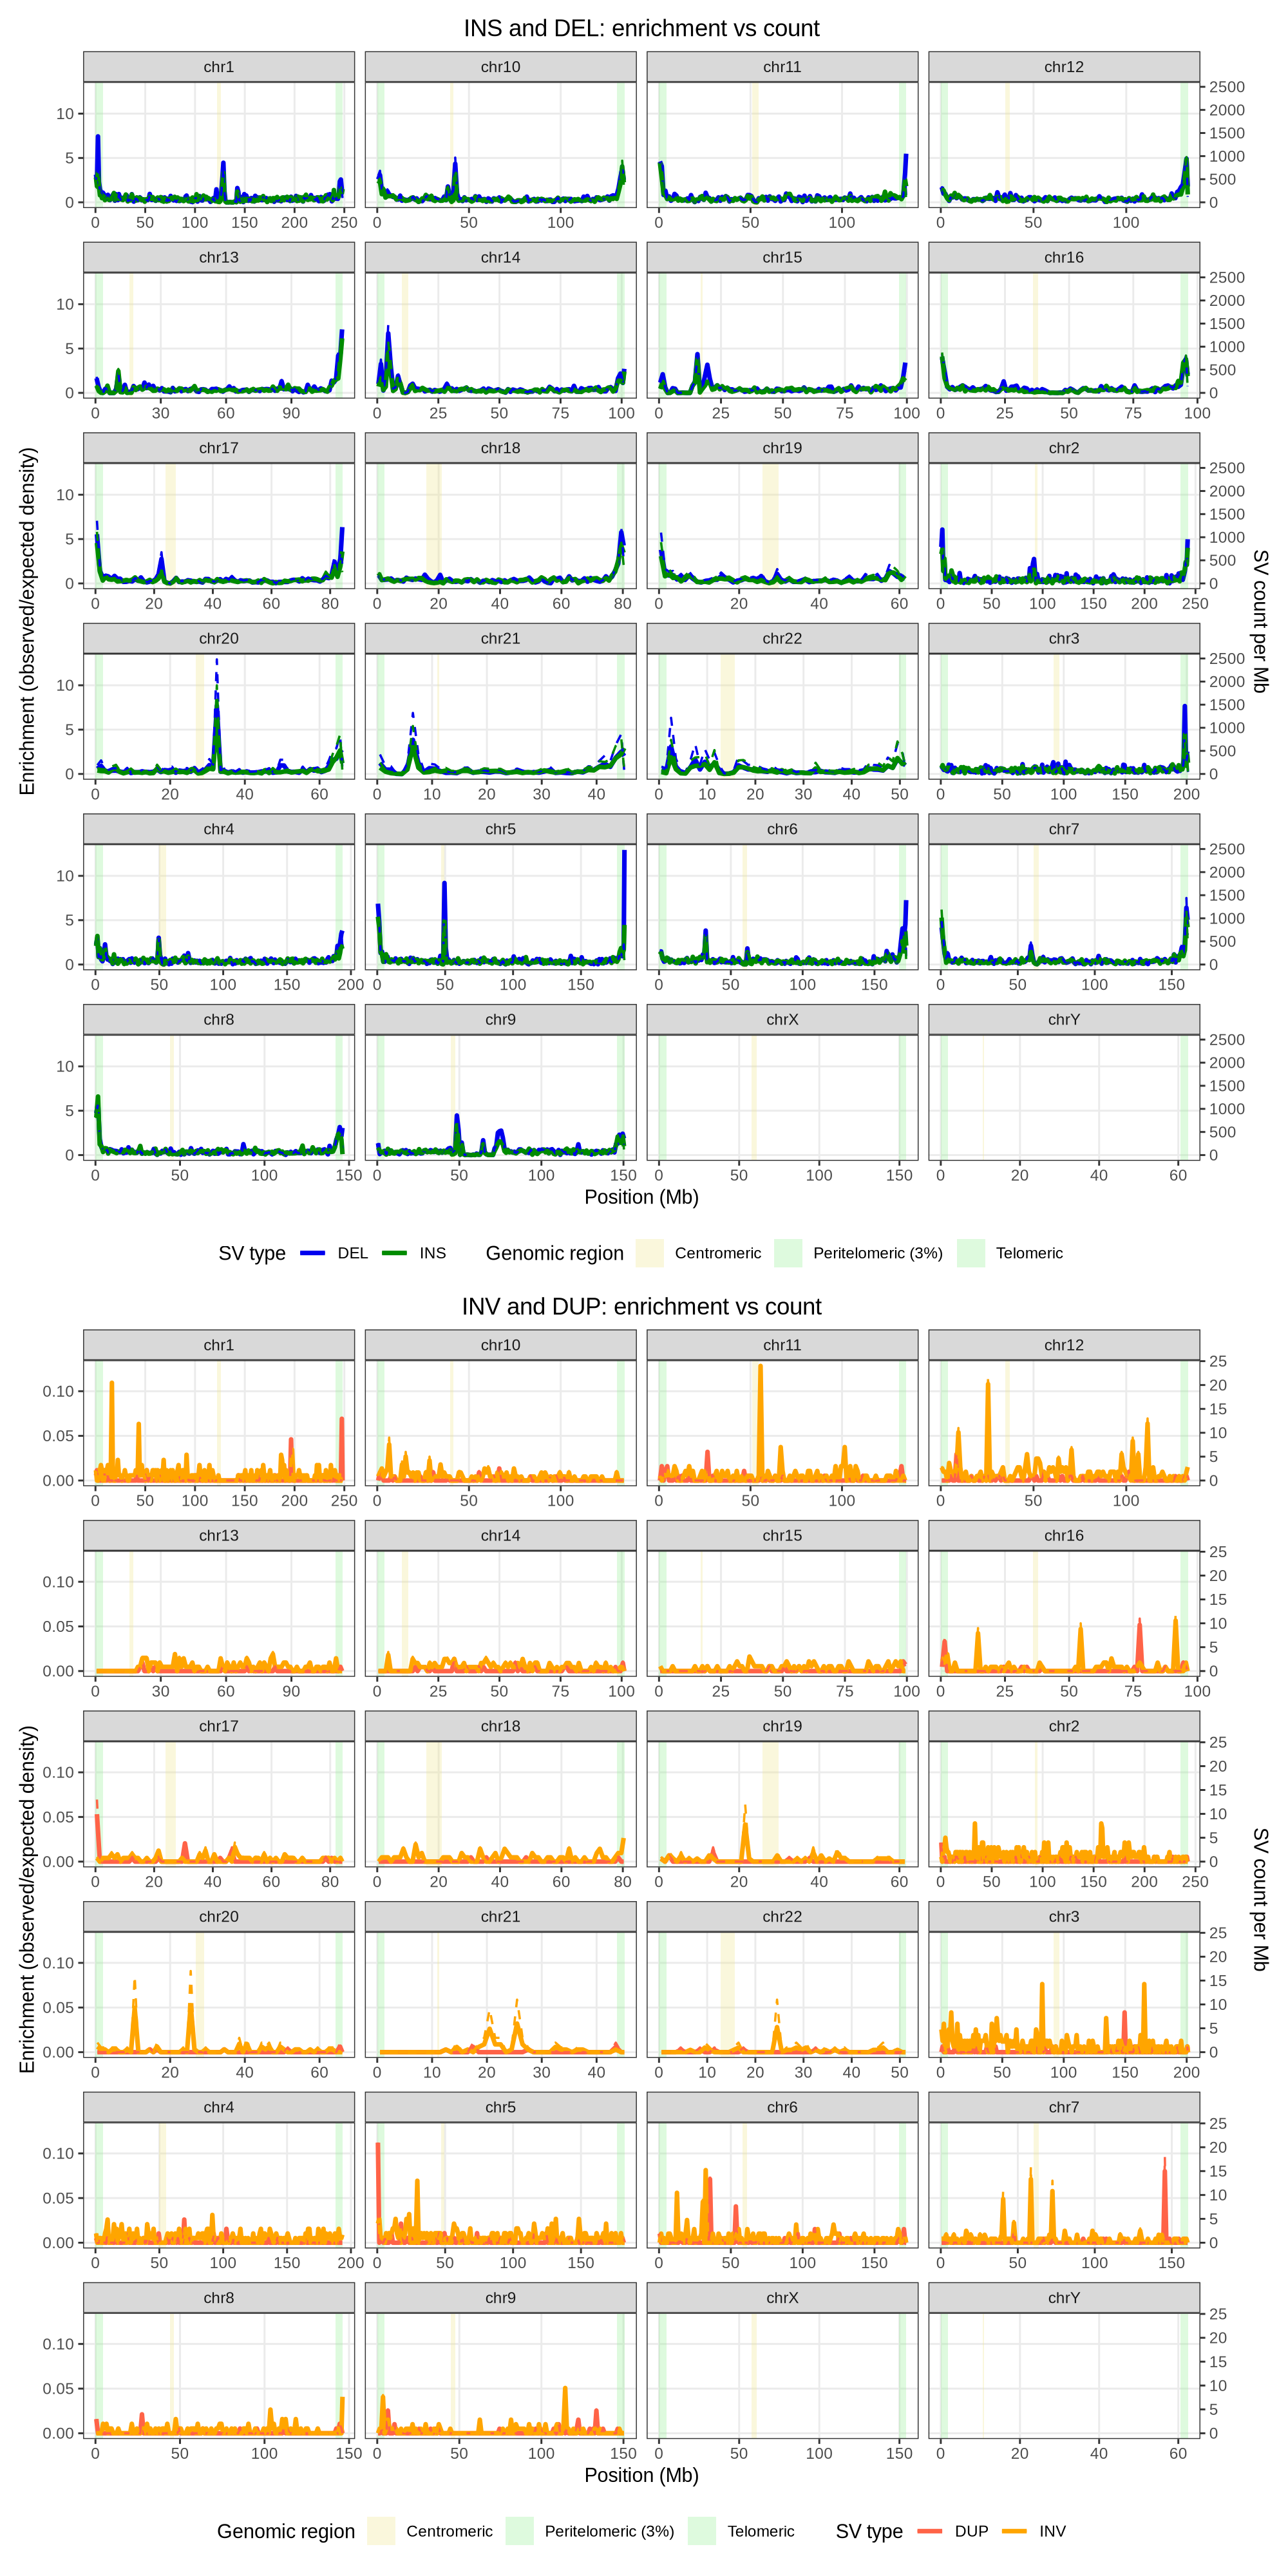

In [22]:
# --------------------------------------------------
# Final plots
# --------------------------------------------------
cols_ins_del <- c(INS = "green4", DEL = "blue2")
cols_inv_dup <- c(INV = "orange", DUP = "tomato")

p1 <- plot_dual_allchr(
  all_counts,
  highlight_regions,
  types = c("INS", "DEL"),
  cols = cols_ins_del,
  title = "INS and DEL: enrichment vs count"
)

p2 <- plot_dual_allchr(
  all_counts,
  highlight_regions,
  types = c("INV", "DUP"),
  cols = cols_inv_dup,
  title = "INV and DUP: enrichment vs count"
)
options(repr.plot.width = 10, repr.plot.height = 20, repr.plot.res = 200)
combined_plot <- p1 / p2
print(combined_plot)

# Example save:
# ggsave(out_file, combined_plot, width = 25, height = 30)